In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Resized_Dataset.zip to Resized_Dataset.zip


In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze the base model
base_model.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [38]:
from google.colab import files
uploaded = files.upload()


Saving Te-me_0011.jpg to Te-me_0011.jpg


In [40]:
print(train_gen.class_indices)


{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [43]:
import os

base_path = '/content/Resized_Dataset/Training'

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder}: {count} images")


glioma: 1321 images
notumor: 1595 images
meningioma: 1339 images
pituitary: 1457 images


In [44]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))


In [52]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight


In [53]:
data_dir = '/content/Resized_Dataset/Training'

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.5, 1.5),
    fill_mode='nearest',
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.


In [54]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))


In [55]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

for layer in base_model.layers[-100:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [56]:
early_stop = EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True)
checkpoint = ModelCheckpoint('resnet50_brain_tumor_best.h5', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)


In [57]:
history = model.fit(
    train_gen,
    epochs=70,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.5745 - loss: 1.0534

143/143 ━━━━━━━━━━━━━━━━━━━━ 124s 477ms/step - accuracy: 0.5755 - loss: 1.0508 - val_accuracy: 0.2507 - val_loss: 1.8017 - learning_rate: 1.0000e-04
Epoch 2/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 36s 250ms/step - accuracy: 0.8788 - loss: 0.3362 - val_accuracy: 0.2314 - val_loss: 1.9642 - learning_rate: 1.0000e-04
Epoch 3/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 39s 271ms/step - accuracy: 0.9244 - loss: 0.2317 - val_accuracy: 0.2358 - val_loss: 2.5979 - learning_rate: 1.0000e-04
Epoch 4/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 243ms/step - accuracy: 0.9344 - loss: 0.2046 - val_accuracy: 0.2585 - val_loss: 3.2202 - learning_rate: 1.0000e-04
Epoch 5/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9397 - loss: 0.2032

143/143 ━━━━━━━━━━━━━━━━━━━━ 46s 323ms/step - accuracy: 0.9397 - loss: 0.2030 - val_accuracy: 0.4181 - val_loss: 1.5274 - learning_rate: 1.0000e-04
Epoch 6/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9552 - loss: 0.1357

143/143 ━━━━━━━━━━━━━━━━━━━━ 80s 313ms/step - accuracy: 0.9552 - loss: 0.1357 - val_accuracy: 0.6319 - val_loss: 1.3670 - learning_rate: 1.0000e-04
Epoch 7/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9610 - loss: 0.1350

...

143/143 ━━━━━━━━━━━━━━━━━━━━ 37s 256ms/step - accuracy: 0.9686 - loss: 0.1136 - val_accuracy: 0.9036 - val_loss: 0.3258 - learning_rate: 1.0000e-04
Epoch 9/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 242ms/step - accuracy: 0.9714 - loss: 0.0910 - val_accuracy: 0.8808 - val_loss: 0.4185 - learning_rate: 1.0000e-04
Epoch 10/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 34s 239ms/step - accuracy: 0.9717 - loss: 0.1012 - val_accuracy: 0.8387 - val_loss: 0.6382 - learning_rate: 1.0000e-04
Epoch 11/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 244ms/step - accuracy: 0.9757 - loss: 0.1071 - val_accuracy: 0.8712 - val_loss: 0.4173 - learning_rate: 1.0000e-04
Epoch 12/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - accuracy: 0.9754 - loss: 0.0771 - val_accuracy: 0.8861 - val_loss: 0.5208 - learning_rate: 1.0000e-04
Epoch 13/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9763 - loss: 0.0791

143/143 ━━━━━━━━━━━━━━━━━━━━ 39s 274ms/step - accuracy: 0.9763 - loss: 0.0792 - val_accuracy: 0.9281 - val_loss: 0.2828 - learning_rate: 1.0000e-04
Epoch 14/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 36s 251ms/step - accuracy: 0.9717 - loss: 0.1050 - val_accuracy: 0.9159 - val_loss: 0.2943 - learning_rate: 1.0000e-04
Epoch 15/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.9756 - loss: 0.0788

143/143 ━━━━━━━━━━━━━━━━━━━━ 42s 293ms/step - accuracy: 0.9756 - loss: 0.0788 - val_accuracy: 0.9439 - val_loss: 0.2035 - learning_rate: 1.0000e-04
Epoch 16/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - accuracy: 0.9792 - loss: 0.0710 - val_accuracy: 0.9176 - val_loss: 0.3542 - learning_rate: 1.0000e-04
Epoch 17/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 240ms/step - accuracy: 0.9817 - loss: 0.0604 - val_accuracy: 0.9316 - val_loss: 0.3227 - learning_rate: 1.0000e-04
Epoch 18/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - accuracy: 0.9847 - loss: 0.0464 - val_accuracy: 0.9334 - val_loss: 0.3059 - learning_rate: 1.0000e-04
Epoch 19/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 247ms/step - accuracy: 0.9871 - loss: 0.0444 - val_accuracy: 0.9071 - val_loss: 0.4224 - learning_rate: 1.0000e-04
Epoch 20/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.9741 - loss: 0.0785
Epoch 20: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 247ms/step -

143/143 ━━━━━━━━━━━━━━━━━━━━ 42s 295ms/step - accuracy: 0.9937 - loss: 0.0233 - val_accuracy: 0.9632 - val_loss: 0.1783 - learning_rate: 4.0000e-06
Epoch 28/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 36s 250ms/step - accuracy: 0.9930 - loss: 0.0224 - val_accuracy: 0.9518 - val_loss: 0.2119 - learning_rate: 4.0000e-06
Epoch 29/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 240ms/step - accuracy: 0.9897 - loss: 0.0260 - val_accuracy: 0.9527 - val_loss: 0.1886 - learning_rate: 4.0000e-06
Epoch 30/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 243ms/step - accuracy: 0.9954 - loss: 0.0203 - val_accuracy: 0.9535 - val_loss: 0.2277 - learning_rate: 4.0000e-06
Epoch 31/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - accuracy: 0.9939 - loss: 0.0191 - val_accuracy: 0.9562 - val_loss: 0.2033 - learning_rate: 4.0000e-06
Epoch 32/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9928 - loss: 0.0227
Epoch 32: ReduceLROnPlateau reducing learning rate to 1e-06.
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 243ms/step - accuracy: 0.9929

143/143 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - accuracy: 0.9936 - loss: 0.0197 - val_accuracy: 0.9588 - val_loss: 0.1724 - learning_rate: 1.0000e-06
Epoch 41/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 36s 249ms/step - accuracy: 0.9970 - loss: 0.0120 - val_accuracy: 0.9623 - val_loss: 0.2046 - learning_rate: 1.0000e-06
Epoch 42/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 276ms/step - accuracy: 0.9953 - loss: 0.0140 - val_accuracy: 0.9562 - val_loss: 0.2375 - learning_rate: 1.0000e-06
Epoch 43/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 243ms/step - accuracy: 0.9950 - loss: 0.0145 - val_accuracy: 0.9527 - val_loss: 0.2052 - learning_rate: 1.0000e-06
Epoch 44/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 39s 269ms/step - accuracy: 0.9971 - loss: 0.0126 - val_accuracy: 0.9527 - val_loss: 0.1941 - learning_rate: 1.0000e-06
Epoch 45/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 243ms/step - accuracy: 0.9969 - loss: 0.0122 - val_accuracy: 0.9518 - val_loss: 0.2139 - learning_rate: 1.0000e-06
Epoch 46/70
143/143 ━━━━━━━━━━━━━━━━━━━━ 35s 241ms/s

In [58]:
final_train_acc = history.history['accuracy'][-1] * 100
final_val_acc = history.history['val_accuracy'][-1] * 100
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"✅ Final Train Accuracy: {final_train_acc:.2f}%")
print(f"✅ Final Validation Accuracy: {final_val_acc:.2f}%")
print(f"📉 Final Train Loss: {final_train_loss:.4f}")
print(f"📉 Final Validation Loss: {final_val_loss:.4f}")


✅ Final Train Accuracy: 99.61%
✅ Final Validation Accuracy: 95.53%
📉 Final Train Loss: 0.0139
📉 Final Validation Loss: 0.2224


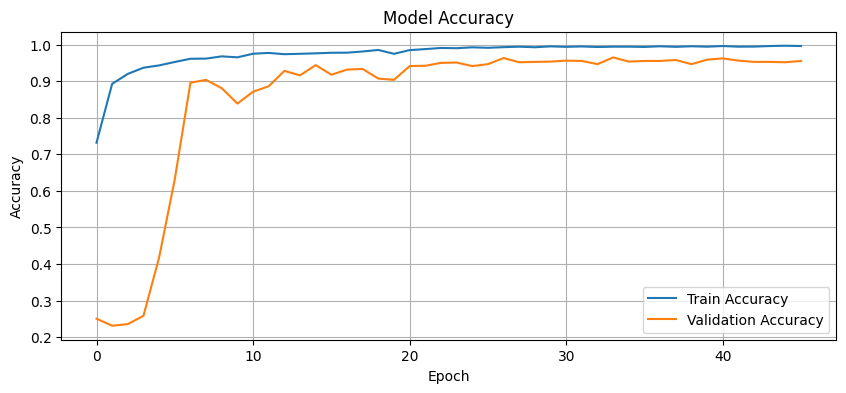

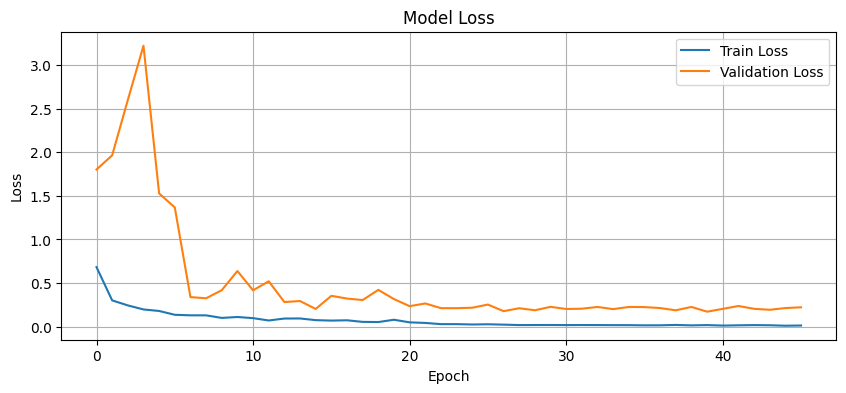

In [59]:
# Accuracy
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [60]:
checkpoint = ModelCheckpoint('resnet50_brain_tumor_best.h5', save_best_only=True)


In [62]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

# Load trained model
model = load_model('resnet50_brain_tumor_best.h5')

# Path to test image (upload it if needed)
img_path = '/content/Te-me_0010.jpg'  # change this to your image path

# Preprocess the image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # normalize
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0]

# Map predictions to class names
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']  # match your folder names

# Show confidence for each class
for i, prob in enumerate(pred):
    print(f"{class_names[i]}: {prob * 100:.2f}%")

print(f"\n Predicted Class: {class_names[np.argmax(pred)]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
glioma: 0.17%
meningioma: 99.77%
notumor: 0.01%
pituitary: 0.05%

 Predicted Class: meningioma


In [64]:
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('resnet50_brain_tumor_best.h5')

# ✅ Change the path to your newly uploaded image
img_path = '/content/Te-me_0011.jpg'  # 🔁 Change this as needed

# Preprocess the image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model.predict(img_array)[0]

# Define your class names (make sure the order matches training)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Display prediction probabilities
for i, prob in enumerate(predictions):
    print(f"{class_names[i]}: {prob*100:.2f}%")

# Show final predicted class
predicted_class = class_names[np.argmax(predictions)]
print(f"\n Predicted Class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
glioma: 0.12%
meningioma: 97.10%
notumor: 1.02%
pituitary: 1.75%

🎯 Predicted Class: meningioma


In [65]:
from google.colab import files
uploaded = files.upload()


Saving Te-pi_0011.jpg to Te-pi_0011.jpg


In [66]:
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('resnet50_brain_tumor_best.h5')

#  Change the path to your newly uploaded image
img_path = '/content/Te-pi_0011.jpg'  # 🔁 Change this as needed

# Preprocess the image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model.predict(img_array)[0]

# Define your class names (make sure the order matches training)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Display prediction probabilities
for i, prob in enumerate(predictions):
    print(f"{class_names[i]}: {prob*100:.2f}%")

# Show final predicted class
predicted_class = class_names[np.argmax(predictions)]
print(f"\n Predicted Class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
glioma: 0.00%
meningioma: 0.00%
notumor: 0.00%
pituitary: 100.00%

 Predicted Class: pituitary


In [67]:
from google.colab import files
uploaded = files.upload()


Saving Te-gl_0011.jpg to Te-gl_0011.jpg


In [68]:
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('resnet50_brain_tumor_best.h5')

#  Change the path to your newly uploaded image
img_path = '/content/Te-pi_0011.jpg'  # 🔁 Change this as needed

# Preprocess the image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model.predict(img_array)[0]

# Define your class names (make sure the order matches training)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Display prediction probabilities
for i, prob in enumerate(predictions):
    print(f"{class_names[i]}: {prob*100:.2f}%")

# Show final predicted class
predicted_class = class_names[np.argmax(predictions)]
print(f"\n Predicted Class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
glioma: 0.00%
meningioma: 0.00%
notumor: 0.00%
pituitary: 100.00%

 Predicted Class: pituitary


In [69]:
from google.colab import files
uploaded = files.upload()


Saving Te-gl_0018.jpg to Te-gl_0018.jpg


In [70]:
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('resnet50_brain_tumor_best.h5')

#  Change the path to your newly uploaded image
img_path = '/content/Te-gl_0018.jpg'  # 🔁 Change this as needed

# Preprocess the image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model.predict(img_array)[0]

# Define your class names (make sure the order matches training)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Display prediction probabilities
for i, prob in enumerate(predictions):
    print(f"{class_names[i]}: {prob*100:.2f}%")

# Show final predicted class
predicted_class = class_names[np.argmax(predictions)]
print(f"\n Predicted Class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
glioma: 100.00%
meningioma: 0.00%
notumor: 0.00%
pituitary: 0.00%

 Predicted Class: glioma


In [71]:
from google.colab import files
uploaded = files.upload()


Saving Te-no_0013.jpg to Te-no_0013.jpg


In [72]:
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('resnet50_brain_tumor_best.h5')

#  Change the path to your newly uploaded image
img_path = '/content/Te-no_0013.jpg'  # 🔁 Change this as needed

# Preprocess the image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model.predict(img_array)[0]

# Define your class names (make sure the order matches training)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Display prediction probabilities
for i, prob in enumerate(predictions):
    print(f"{class_names[i]}: {prob*100:.2f}%")

# Show final predicted class
predicted_class = class_names[np.argmax(predictions)]
print(f"\n Predicted Class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
glioma: 0.00%
meningioma: 0.02%
notumor: 99.98%
pituitary: 0.00%

 Predicted Class: notumor


In [73]:
from google.colab import files
uploaded = files.upload()


Saving Te-me_0015.jpg to Te-me_0015.jpg


In [74]:
from tensorflow.keras.preprocessing import image
import numpy as np
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model('resnet50_brain_tumor_best.h5')

#  Change the path to your newly uploaded image
img_path = '/content/Te-me_0015.jpg'

# Preprocess the image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
predictions = model.predict(img_array)[0]

# Define your class names (make sure the order matches training)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# Display prediction probabilities
for i, prob in enumerate(predictions):
    print(f"{class_names[i]}: {prob*100:.2f}%")

# Show final predicted class
predicted_class = class_names[np.argmax(predictions)]
print(f"\n Predicted Class: {predicted_class}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
glioma: 0.00%
meningioma: 99.39%
notumor: 0.05%
pituitary: 0.56%

 Predicted Class: meningioma


In [75]:
!pip install flask-ngrok
!pip install tensorflow
